In [1]:
library(tidyverse)

options(repr.plot.width = 16, repr.plot.height = 9)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
df <- read_csv(file = "c71fea2e-d00b-42f2-90a7-bd2d9b0055dd_Data.csv")
df |> head()

Rows: 9 Columns: 70
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (19): Country Name, Country Code, Series Name, Series Code, 1960 [YR1960...
dbl (51): 1975 [YR1975], 1976 [YR1976], 1977 [YR1977], 1978 [YR1978], 1979 [...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Country Name,Country Code,Series Name,Series Code,1960 [YR1960],1961 [YR1961],1962 [YR1962],1963 [YR1963],1964 [YR1964],1965 [YR1965],⋯,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Brazil,BRA,GDP (constant 2015 US$),NY.GDP.MKTP.KD,188463862170.398,204671754317.052,218180090101.977,219489170642.589,226951802444.437,232398645703.104,⋯,1.743173e+12,1.766233e+12,1.797737e+12,1.819683e+12,1.760057e+12,1.843881e+12,1.899505e+12,1.961081e+12,2.028136e+12,2.074494e+12
Brazil,BRA,Gross savings (% of GDP),NY.GNS.ICTR.ZS,..,..,..,..,..,..,⋯,1.342175e+01,1.357777e+01,1.270742e+01,1.230640e+01,1.484008e+01,1.721702e+01,1.588751e+01,1.503950e+01,1.414115e+01,1.441559e+01
Brazil,BRA,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,..,..,..,..,..,..,⋯,4.137378e+00,3.338260e+00,4.078588e+00,3.692673e+00,2.592638e+00,2.779791e+00,3.868032e+00,2.863833e+00,3.389608e+00,3.406969e+00
Brazil,BRA,Population growth (annual %),SP.POP.GROW,..,3.01712402135294,2.98413178984127,2.94697800169989,2.89384532588109,2.81797346768923,⋯,7.619727e-01,7.282467e-01,6.834396e-01,6.519943e-01,5.793507e-01,4.253609e-01,3.601809e-01,3.959287e-01,4.054670e-01,3.831506e-01
NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [3]:
dados <- setNames(data.frame(df[1:4, 5:ncol(df)] |> t(), row.names = NULL), c("PIB", "PB", "IED", "CP")) %>% 
    mutate(across(everything(), as.numeric))
dados$Ano <- 1960:2025
dados

Warning message:
“There were 3 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across(everything(), as.numeric)`.
Caused by warning:
! NAs introduzidos por coerção
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”


PIB,PB,IED,CP,Ano
<dbl>,<dbl>,<dbl>,<dbl>,<int>
188463862170,NA,NA,NA,1960
204671754317,NA,NA,3.017124,1961
218180090102,NA,NA,2.984132,1962
219489170643,NA,NA,2.946978,1963
226951802444,NA,NA,2.893845,1964
232398645703,NA,NA,2.817973,1965
247969354965,NA,NA,2.732363,1966
258384067874,NA,NA,2.642716,1967
283705706525,NA,NA,2.561834,1968


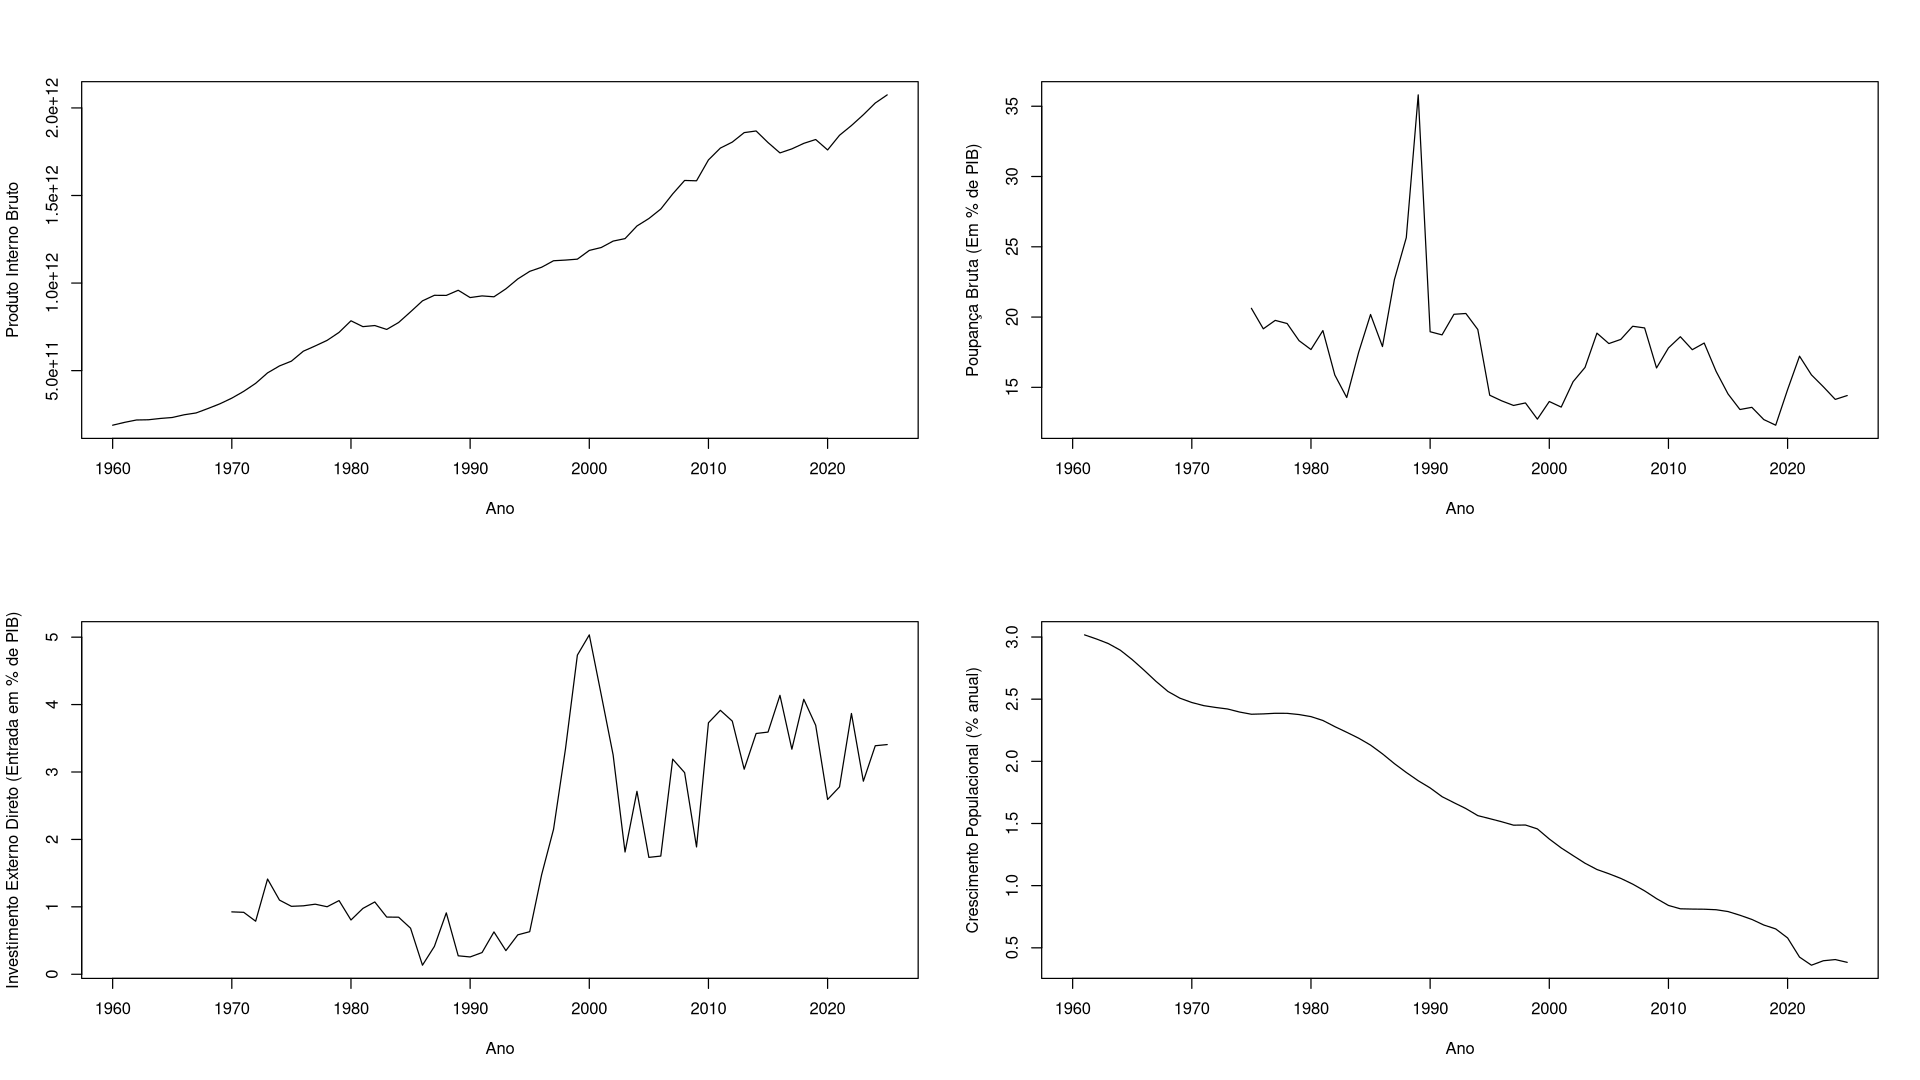

In [5]:
par(mfrow = c(2,2))
plot(x = dados$Ano, y = dados$PIB,  type='l', xlab = "Ano", ylab = "Produto Interno Bruto")
plot(x = dados$Ano, y = dados$PB,   type='l', xlab = "Ano", ylab = "Poupança Bruta (Em % de PIB)")
plot(x = dados$Ano, y = dados$IED,  type='l', xlab = "Ano", ylab = "Investimento Externo Direto (Entrada em % de PIB)")
plot(x = dados$Ano, y = dados$CP,   type='l', xlab = "Ano", ylab = "Crescimento Populacional (% anual)")

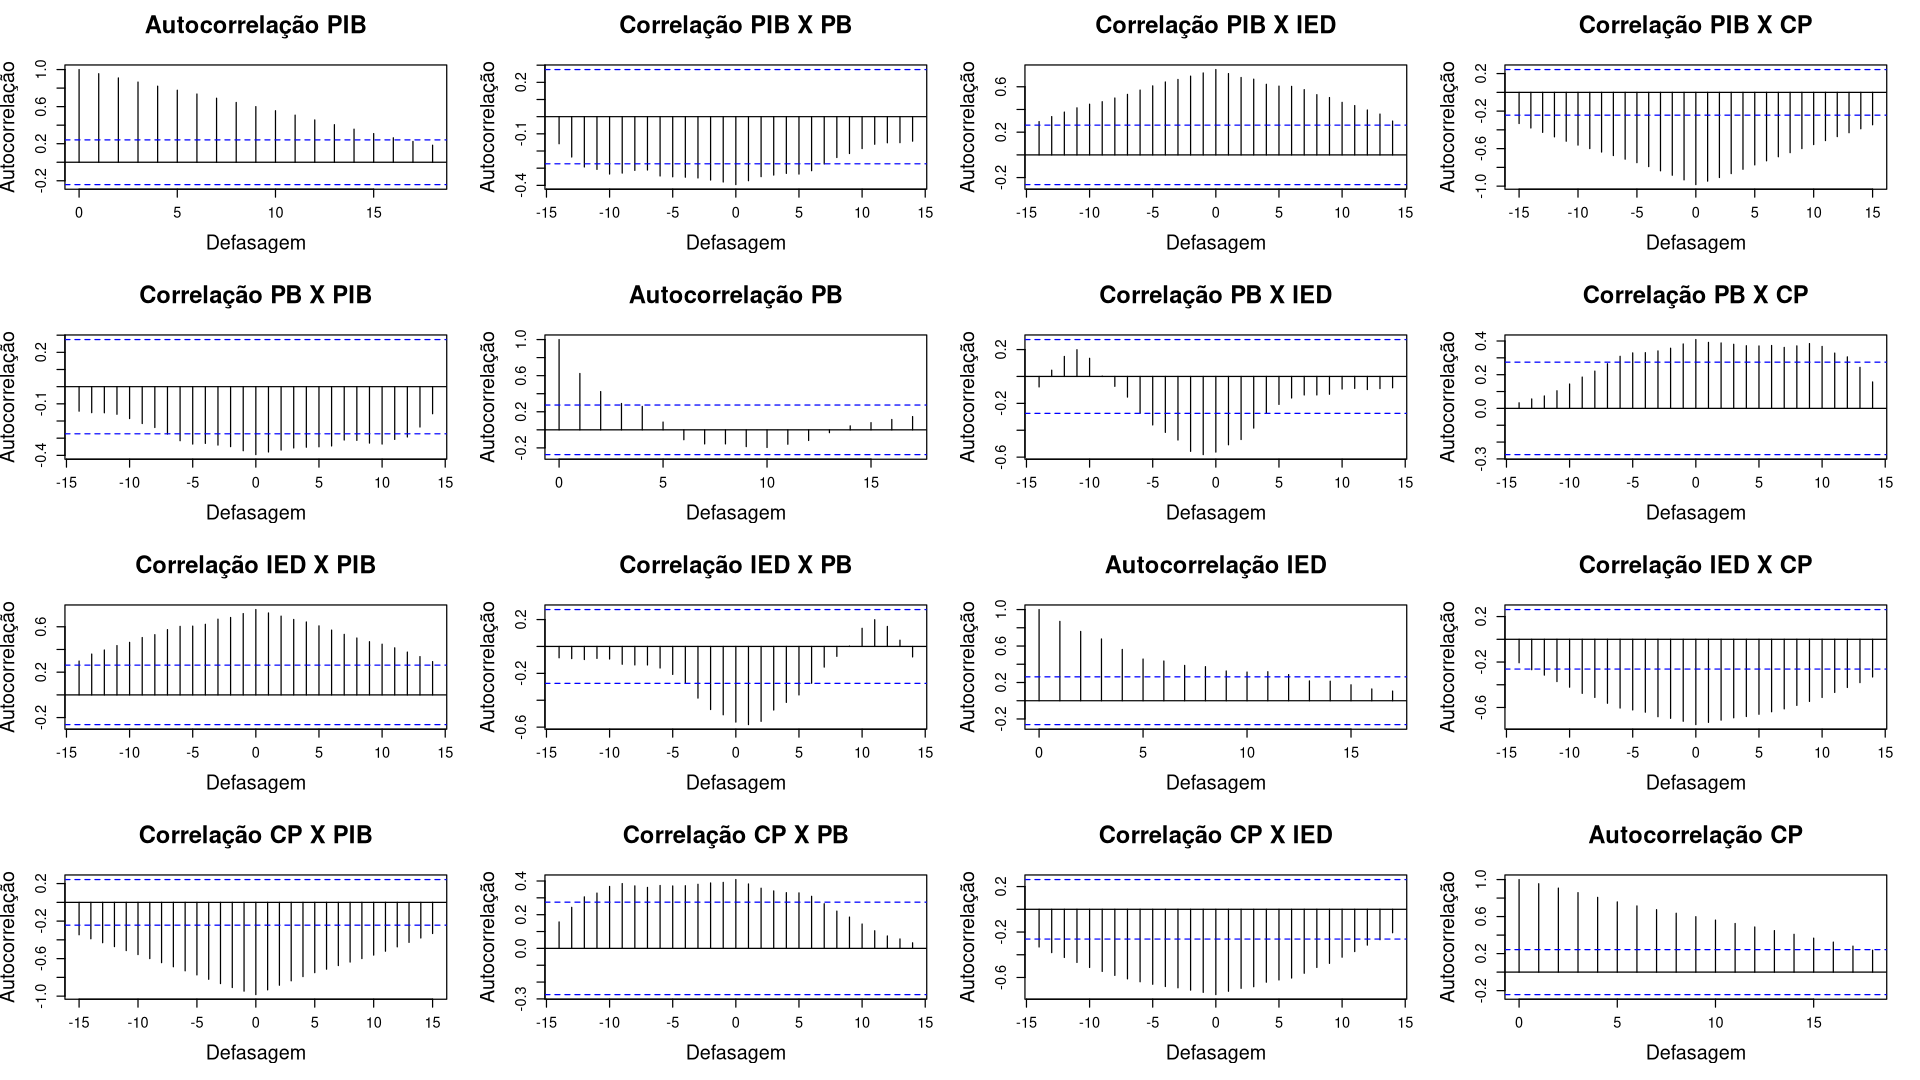

In [27]:
par(mfrow = c(4, 4), cex.main = 1.8, cex.axis = 1.1, cex.lab = 1.5)
for (i in 1:4) {
   for (j in 1:4) {
      if (i == j) {
         acf(dados[,i], na.action = na.exclude, main = paste0("Autocorrelação ", colnames(dados)[i]),    xlab = "Defasagem", ylab = "Autocorrelação")
      } else {
        ccf(dados[,i], dados[,j], na.action = na.exclude, main = paste0("Correlação ", colnames(dados)[i], " X ", colnames(dados)[j]),    xlab = "Defasagem", ylab = "Autocorrelação")
      }
   }
}

In [30]:
modelo <- lm(formula = log(PIB) ~ log(PB) + log(IED) + log(CP), data = dados)
summary(modelo)


Call:
lm(formula = log(PIB) ~ log(PB) + log(IED) + log(CP), data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.35823 -0.06008  0.03266  0.08575  0.17150 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 27.74797    0.32844  84.484   <2e-16 ***
log(PB)      0.05119    0.11332   0.452   0.6535    
log(IED)     0.05481    0.02987   1.835   0.0728 .  
log(CP)     -0.58207    0.04299 -13.541   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1245 on 47 degrees of freedom
  (15 observations deleted due to missingness)
Multiple R-squared:  0.8965,	Adjusted R-squared:  0.8899 
F-statistic: 135.7 on 3 and 47 DF,  p-value: < 2.2e-16


In [ ]:
modeloRobusto <- MASS::rlm(
    formula = log(PIB) ~ log(PB) + log(IED) + log(CP), 
    data = dados, psi = MASS::psi.huber, maxit = 100
)
lmtest::coeftest(modeloRobusto)


z test of coefficients:

             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) 27.601575   0.279802  98.6470  < 2e-16 ***
log(PB)      0.110679   0.096535   1.1465  0.25158    
log(IED)     0.059281   0.025444   2.3299  0.01981 *  
log(CP)     -0.603182   0.036620 -16.4713  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
